# Exploratory Data Analysis (EDA)

## Gerekli Yapıları import edelim

In [170]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
plt.style.use('ggplot')

## Verileri okuyalım

In [171]:
df = pd.read_excel("../data/Talent_Academy_Case_DT_2025.xlsx", sheet_name=0)

## Veriyi anlayalım

In [172]:
df.shape
#(row,column) yani toplam veri sayısı, toplam değişken sayısı

(2235, 13)

In [173]:
df.head(3)

,HastaNo,Yas,Cinsiyet,KanGrubu,Uyruk,KronikHastalik,Bolum,Alerji,Tanilar,TedaviAdi,TedaviSuresi,UygulamaYerleri,UygulamaSuresi
0,145134,60,Kadın,0 Rh+,Türkiye,"Becker Musküler Distrofisi, Hiportiroidizm, Ka...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",TOZ,Ayak bileği ve ayağın yüzeysel yaralanması,Ayak Bileği,5 Seans,Ayak Bileği,20 Dakika
1,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,Boyun,20 Dakika
2,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,"Boyun,Sırt",20 Dakika


In [174]:
df.columns

Index(['HastaNo', 'Yas', 'Cinsiyet', 'KanGrubu', 'Uyruk', 'KronikHastalik',
       'Bolum', 'Alerji', 'Tanilar', 'TedaviAdi', 'TedaviSuresi',
       'UygulamaYerleri', 'UygulamaSuresi'],
      dtype='object')

In [175]:
df.dtypes

HastaNo             int64
Yas                 int64
Cinsiyet           object
KanGrubu           object
Uyruk              object
KronikHastalik     object
Bolum              object
Alerji             object
Tanilar            object
TedaviAdi          object
TedaviSuresi       object
UygulamaYerleri    object
UygulamaSuresi     object
dtype: object

In [176]:
df.describe()

,HastaNo,Yas
count,2235.000000,2235.000000
mean,145333.100224,47.327069
std,115.214248,15.208634
min,145134.000000,2.000000
25%,145235.000000,38.000000
50%,145331.000000,46.000000
75%,145432.000000,56.000000
max,145537.000000,92.000000


## Veri hazırlama

In [177]:
df.head()

,HastaNo,Yas,Cinsiyet,KanGrubu,Uyruk,KronikHastalik,Bolum,Alerji,Tanilar,TedaviAdi,TedaviSuresi,UygulamaYerleri,UygulamaSuresi
0,145134,60,Kadın,0 Rh+,Türkiye,"Becker Musküler Distrofisi, Hiportiroidizm, Ka...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",TOZ,Ayak bileği ve ayağın yüzeysel yaralanması,Ayak Bileği,5 Seans,Ayak Bileği,20 Dakika
1,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,Boyun,20 Dakika
2,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,"Boyun,Sırt",20 Dakika
3,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,Boyun,5 Dakika
4,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,"Boyun,Sırt",20 Dakika


In [178]:
df.isna().sum()

HastaNo              0
Yas                  0
Cinsiyet           169
KanGrubu           675
Uyruk                0
KronikHastalik     611
Bolum               11
Alerji             944
Tanilar             75
TedaviAdi            0
TedaviSuresi         0
UygulamaYerleri    221
UygulamaSuresi       0
dtype: int64

In [179]:
df.loc[df.duplicated()]

,HastaNo,Yas,Cinsiyet,KanGrubu,Uyruk,KronikHastalik,Bolum,Alerji,Tanilar,TedaviAdi,TedaviSuresi,UygulamaYerleri,UygulamaSuresi
4,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,"Boyun,Sırt",20 Dakika
5,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15 Seans,Boyun,20 Dakika
8,145136,60,Erkek,0 Rh+,Türkiye,NaN,"Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi","POLEN,NOVALGIN",Parapleji ve tetrapleji,Parapleji,10 Seans,NaN,20 Dakika
11,145137,65,Kadın,0 Rh+,Türkiye,"Hiportiroidizm, Diyabet, Duchenne Musküler Dis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NOVALGIN,"Artroz, tanımlanmamış, el",El rehabilitasyonu,15 Seans,Sol El Bilek Bölgesi,20 Dakika
14,145137,65,Kadın,0 Rh+,Türkiye,"Hiportiroidizm, Diyabet, Duchenne Musküler Dis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NOVALGIN,"Artroz, tanımlanmamış, el",El rehabilitasyonu,15 Seans,Sol El Bilek Bölgesi,20 Dakika
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225,145535,52,Kadın,NaN,Türkiye,Hipertansiyon,"Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",POLEN,Omuzun darbe sendromu,Sol omuz İmpingement,15 Seans,Sol Omuz Bölgesi,20 Dakika
2226,145535,52,Kadın,NaN,Türkiye,Hipertansiyon,"Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",POLEN,Omuzun darbe sendromu,Sol omuz İmpingement,15 Seans,Sol Omuz Bölgesi,20 Dakika
2227,145535,52,Kadın,NaN,Türkiye,Hipertansiyon,"Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",POLEN,Omuzun darbe sendromu,Sol omuz İmpingement,15 Seans,Sol Omuz Bölgesi,20 Dakika
2229,145536,48,Erkek,NaN,Türkiye,"Aritmi, Myastenia gravis, Fascioscapulohumeral...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi","ARVELES,CORASPIN",Eklemin kontraktürü,Ekstansör tendon Rehabilitasyon,15 Seans,Sol El Bilek Bölgesi,20 Dakika


In [180]:
df = df.drop_duplicates()

In [181]:
df.shape

(1307, 13)

In [182]:

df.loc[:, "TedaviSuresi"] = df["TedaviSuresi"].astype(str).str.replace("Seans", "").str.strip()
df.loc[:, "UygulamaSuresi"] = df["UygulamaSuresi"].astype(str).str.replace("Dakika", "").str.strip()

df.loc[:, "TedaviSuresi"] = pd.to_numeric(df["TedaviSuresi"], errors="coerce").astype("Int64")
df.loc[:, "UygulamaSuresi"] = pd.to_numeric(df["UygulamaSuresi"], errors="coerce").astype("Int64")


In [183]:
df.head(3)

,HastaNo,Yas,Cinsiyet,KanGrubu,Uyruk,KronikHastalik,Bolum,Alerji,Tanilar,TedaviAdi,TedaviSuresi,UygulamaYerleri,UygulamaSuresi
0,145134,60,Kadın,0 Rh+,Türkiye,"Becker Musküler Distrofisi, Hiportiroidizm, Ka...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",TOZ,Ayak bileği ve ayağın yüzeysel yaralanması,Ayak Bileği,5,Ayak Bileği,20
1,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15,Boyun,20
2,145135,28,Erkek,0 Rh+,Türkiye,"Duchenne Musküler Distrofisi, Myastenia gravis...","Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi",NaN,"Omuzun darbe sendromu,DORSALJİ, DİĞER, SERVİKO...",Dorsalji -Boyun+trapez+skapular,15,"Boyun,Sırt",20


## Hedef deği̇şken anali̇zi̇ (tedavisuresi)



In [184]:
print("Basic Statistics for TedaviSuresi:")
print(df['TedaviSuresi'].describe())

Basic Statistics for TedaviSuresi:
count     1307
unique      23
top         15
freq       938
Name: TedaviSuresi, dtype: int64


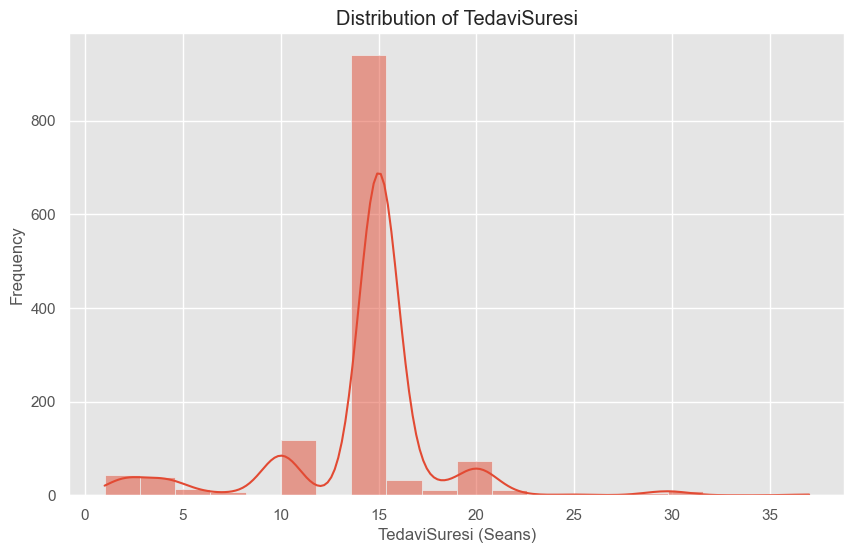

In [185]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TedaviSuresi'], bins=20, kde=True)
plt.title('Distribution of TedaviSuresi')
plt.xlabel('TedaviSuresi (Seans)')
plt.ylabel('Frequency')
plt.show()

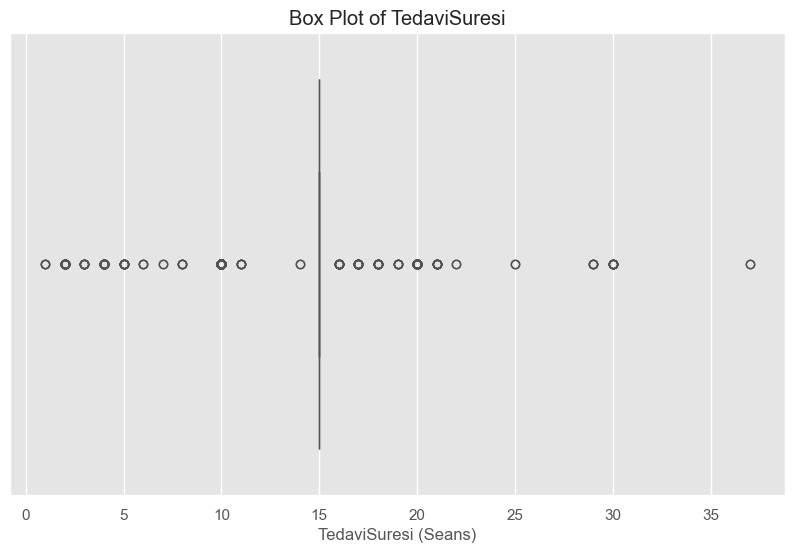

In [186]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['TedaviSuresi'])
plt.title('Box Plot of TedaviSuresi')
plt.xlabel('TedaviSuresi (Seans)')
plt.show()

In [187]:
print("\nSummary Statistics for TedaviSuresi:")
print(f"Mean: {df['TedaviSuresi'].mean():.2f}")
print(f"Median: {df['TedaviSuresi'].median():.2f}")
print(f"Minimum: {df['TedaviSuresi'].min():.2f}")
print(f"Maximum: {df['TedaviSuresi'].max():.2f}")


Summary Statistics for TedaviSuresi:
Mean: 14.23
Median: 15.00
Minimum: 1.00
Maximum: 37.00


## Eksi̇k veri̇ kontrolü

Missing values per column:
HastaNo              0
Yas                  0
Cinsiyet           104
KanGrubu           365
Uyruk                0
KronikHastalik     345
Bolum                7
Alerji             540
Tanilar             46
TedaviAdi            0
TedaviSuresi         0
UygulamaYerleri    157
UygulamaSuresi       0
dtype: int64

Total Missing Cells: 1564
Percentage of Missing Cells: 9.2%


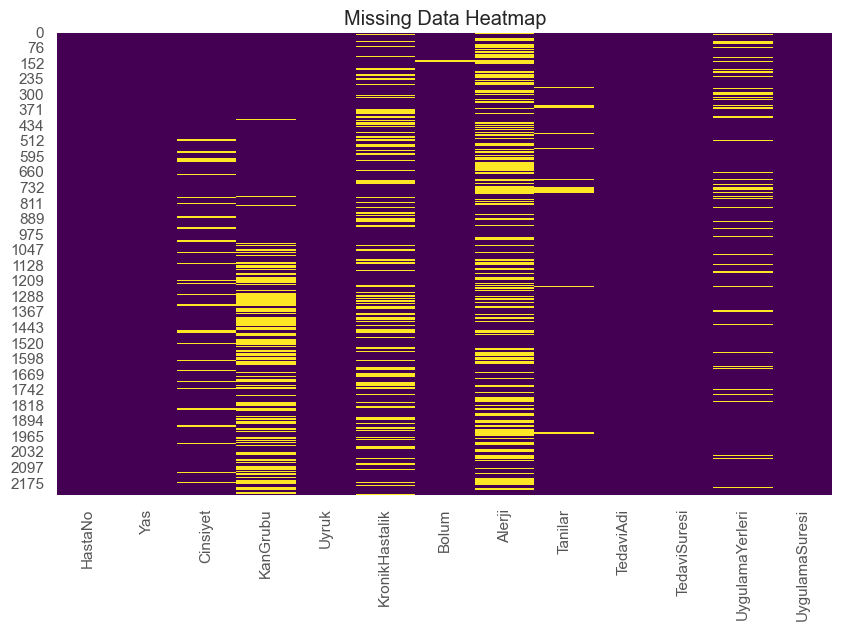

In [188]:
print("Missing values per column:")
print(df.isnull().sum())

missing_cells = df.isnull().sum().sum()

total_cells = df.shape[0] * df.shape[1]

missing_percent = (missing_cells / total_cells) * 100

print(f"\nTotal Missing Cells: {missing_cells}")
print(f"Percentage of Missing Cells: {missing_percent:.1f}%")

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Missing Data Heatmap')

plt.show()

## Sayisal deği̇şkenler

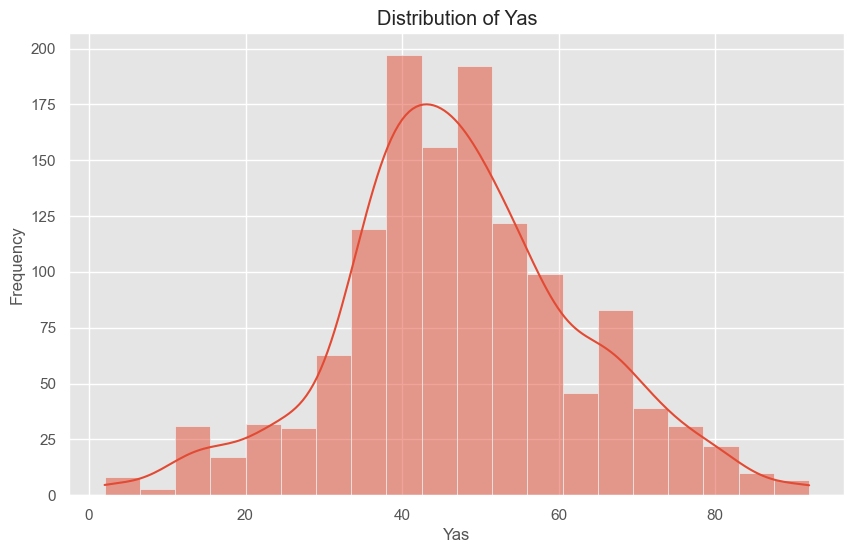

In [189]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yas'], bins=20, kde=True)
plt.title('Distribution of Yas')
plt.xlabel('Yas')
plt.ylabel('Frequency')
plt.show()

In [190]:
numerical_df = df[['Yas', 'UygulamaSuresi', 'TedaviSuresi']]
correlation_matrix = numerical_df.corr()

display(correlation_matrix)

,Yas,UygulamaSuresi,TedaviSuresi
Yas,1.000000,-0.009343,-0.023295
UygulamaSuresi,-0.009343,1.000000,0.045428
TedaviSuresi,-0.023295,0.045428,1.000000


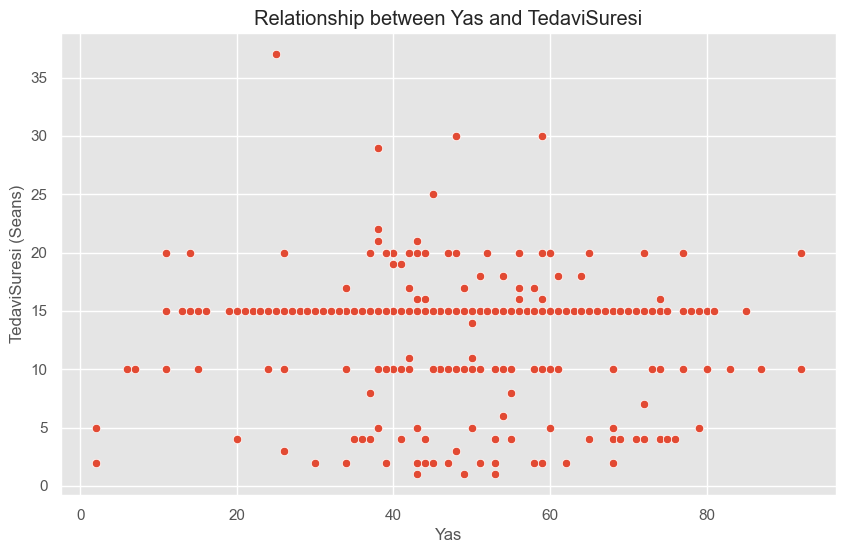

In [191]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Yas', y='TedaviSuresi')
plt.title('Relationship between Yas and TedaviSuresi')
plt.xlabel('Yas')
plt.ylabel('TedaviSuresi (Seans)')
plt.show()

## Kategori̇k deği̇şkenler

Frequency Distribution for Cinsiyet:
Cinsiyet
Kadın    723
Erkek    480
Name: count, dtype: int64


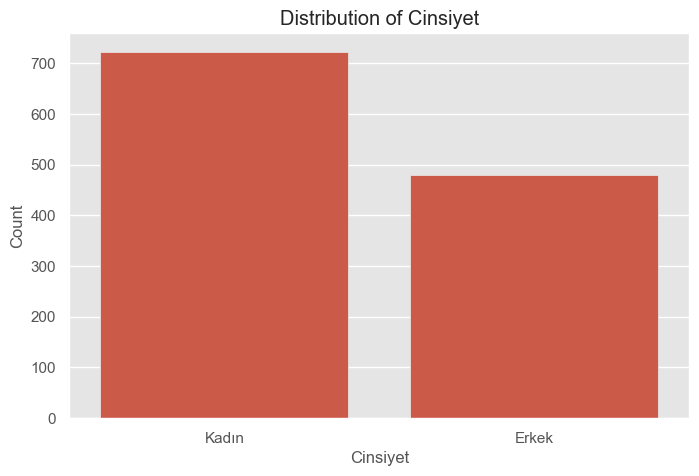

In [192]:
print("Frequency Distribution for Cinsiyet:")
print(df['Cinsiyet'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Cinsiyet', order=df['Cinsiyet'].value_counts().index)
plt.title('Distribution of Cinsiyet')
plt.xlabel('Cinsiyet')
plt.ylabel('Count')
plt.show()


Frequency Distribution for KanGrubu:
KanGrubu
0 Rh+     353
A Rh+     321
B Rh+     124
AB Rh+     51
B Rh-      41
A Rh-      29
0 Rh-      17
AB Rh-      6
Name: count, dtype: int64


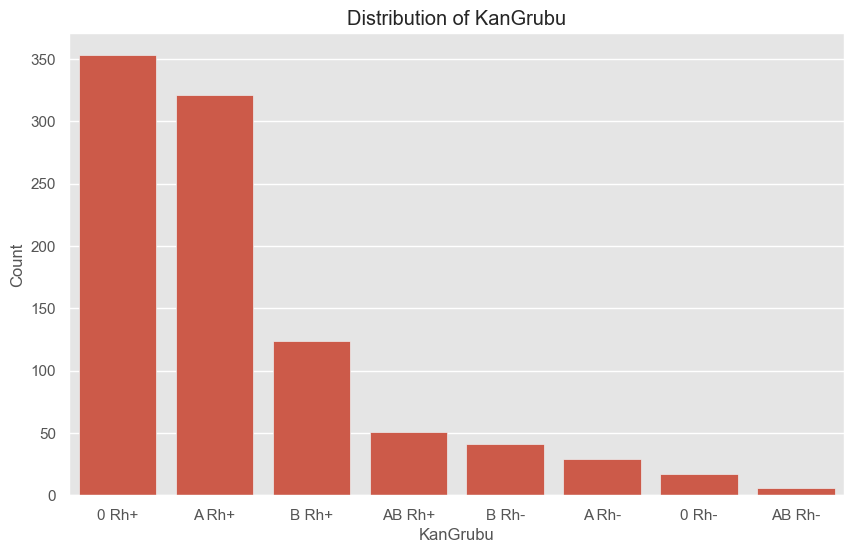

In [193]:
print("\nFrequency Distribution for KanGrubu:")
print(df['KanGrubu'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='KanGrubu', order=df['KanGrubu'].value_counts().index)
plt.title('Distribution of KanGrubu')
plt.xlabel('KanGrubu')
plt.ylabel('Count')
plt.show()


Frequency Distribution for Uyruk:
Uyruk
Türkiye       1268
Tokelau         16
Arnavutluk      10
Azerbaycan       8
Libya            5
Name: count, dtype: int64


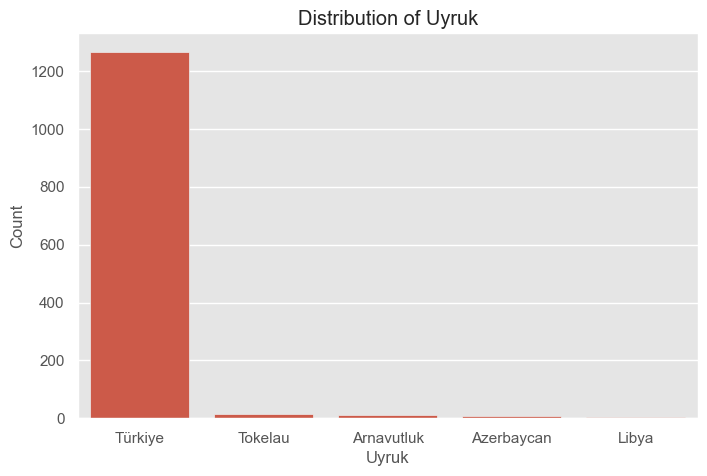

In [194]:
print("\nFrequency Distribution for Uyruk:")
print(df['Uyruk'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Uyruk', order=df['Uyruk'].value_counts().index)
plt.title('Distribution of Uyruk')
plt.xlabel('Uyruk')
plt.ylabel('Count')
plt.show()


Frequency Distribution for Bolum:
Bolum
Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi    1157
Ortopedi Ve Travmatoloji                            78
İç Hastalıkları                                     22
Nöroloji                                            13
Kardiyoloji                                          9
Genel Cerrahi                                        5
Göğüs Hastalıkları                                   5
Laboratuar                                           5
Tıbbi Onkoloji                                       4
Kalp Ve Damar Cerrahisi                              2
Name: count, dtype: int64


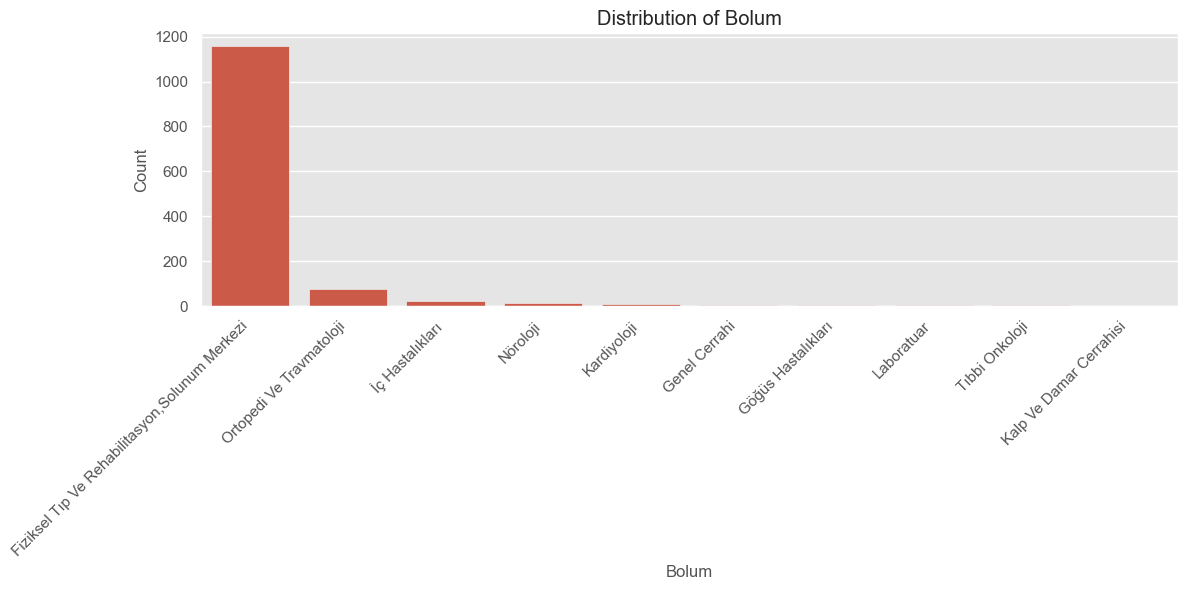

In [195]:
print("\nFrequency Distribution for Bolum:")
print(df['Bolum'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Bolum', order=df['Bolum'].value_counts().index)
plt.title('Distribution of Bolum')
plt.xlabel('Bolum')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Frequency Distribution for TedaviAdi:
TedaviAdi
Dorsalji -Boyun+trapez        120
İV DİSK BOZUKLUĞU-BEL         104
Dorsalji 1                     59
Dorsalji-Bel                   56
Gonartroz-Meniskopati          54
                             ... 
Sol  ÖÇB Rehabilitasyonu-1      1
Spinal manüpilasyon             1
İmpingement op izometrik        1
xx                              1
Ayak Bileği                     1
Name: count, Length: 244, dtype: int64


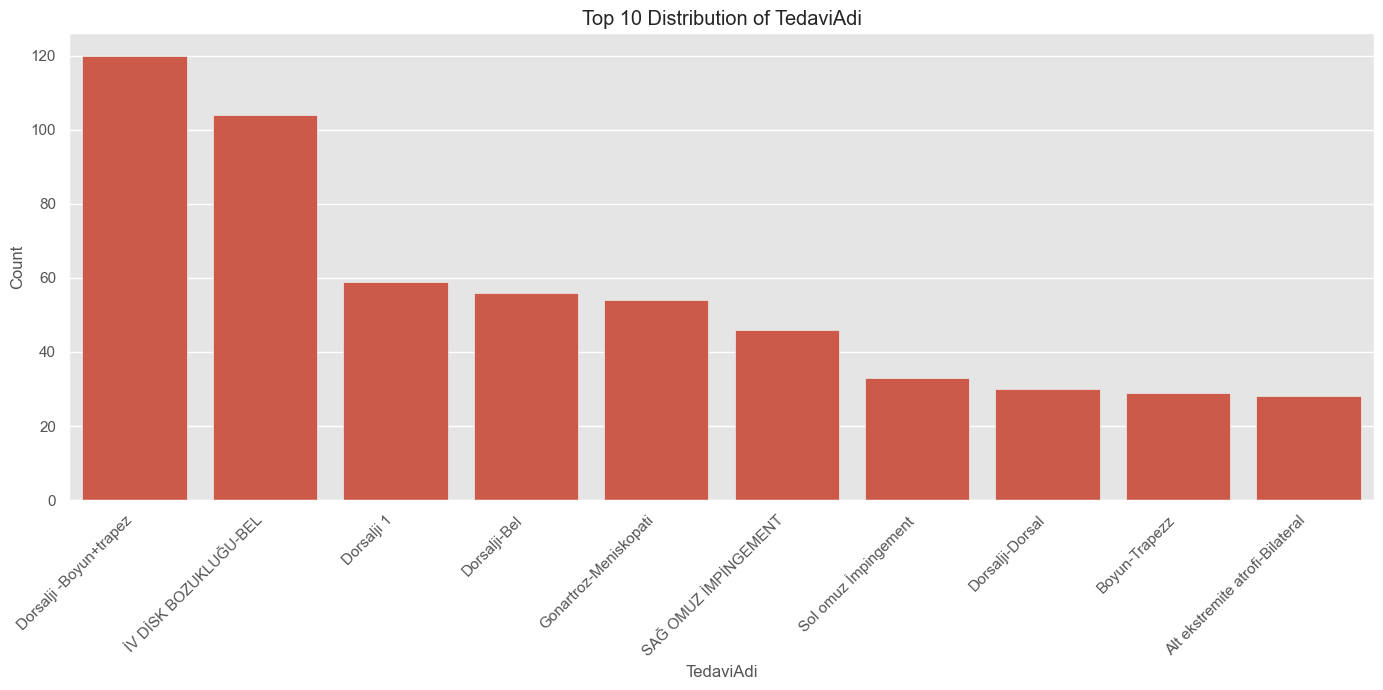

In [196]:
print("\nFrequency Distribution for TedaviAdi:")
print(df['TedaviAdi'].value_counts())

plt.figure(figsize=(14, 7))
top_10_tedavi = df['TedaviAdi'].value_counts().nlargest(10).index
sns.countplot(data=df[df['TedaviAdi'].isin(top_10_tedavi)], x='TedaviAdi', order=top_10_tedavi)
plt.title('Top 10 Distribution of TedaviAdi')
plt.xlabel('TedaviAdi')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Karmaşik meti̇n alanlari

In [197]:
from collections import Counter

complex_text_cols = ['KronikHastalik', 'Alerji', 'Tanilar', 'UygulamaYerleri']

for col in complex_text_cols:
    print(f"\nAnalyzing '{col}':")

    items = df[col].dropna().str.split(',')

    flattened_items = [item.strip() for sublist in items for item in sublist if item.strip()]

    item_counts = Counter(flattened_items)

    print("Top 10 most common items:")
    for item, count in item_counts.most_common(10):
        print(f"- {item}: {count}")


Analyzing 'KronikHastalik':
Top 10 most common items:
- Limb-Girdle Musküler Distrofi: 230
- Aritmi: 228
- Hiportiroidizm: 227
- Astım: 203
- Hipertiroidizm: 190
- Duchenne Musküler Distrofisi: 184
- Myastenia gravis: 182
- Hipertansiyon: 175
- Kalp yetmezliği: 171
- Diyabet: 171

Analyzing 'Alerji':
Top 10 most common items:
- Polen: 197
- POLEN: 99
- Toz: 81
- TOZ: 75
- NOVALGIN: 71
- Sucuk: 56
- ARVELES: 55
- CORASPIN: 55
- Yer Fıstığı: 51
- SUCUK: 48

Analyzing 'Tanilar':
Top 10 most common items:
- DORSALJİ: 376
- DİĞER: 364
- tanımlanmamış: 220
- Omuzun darbe sendromu: 162
- İntervertebral disk bozuklukları: 129
- LUMBOSAKRAL BÖLGE: 128
- SERVİKOTORASİK BÖLGE: 118
- SERVİKAL BÖLGE: 90
- Eklem ağrısı: 68
- Dorsalji: 57

Analyzing 'UygulamaYerleri':
Top 10 most common items:
- Bel: 270
- Boyun: 202
- Diz: 105
- Sağ Omuz Bölgesi: 91
- Sol Omuz Bölgesi: 76
- Tüm Vücut Bölgesi: 61
- Sol El Bilek Bölgesi: 55
- Sırt: 53
- Sağ Ayak Bileği Bölgesi: 47
- Sol Ayak Bileği Bölgesi: 44


## Deği̇şken i̇li̇şki̇leri̇

In [198]:
avg_tedavisuresi_by_cinsiyet = df.groupby('Cinsiyet')['TedaviSuresi'].mean()
print("Average TedaviSuresi by Cinsiyet:")
print(avg_tedavisuresi_by_cinsiyet)

age_bins = [0, 18, 30, 45, 60, df['Yas'].max()]
age_labels = ['0-18', '19-30', '31-45', '46-60', '60+']
df['Yas_Grubu'] = pd.cut(df['Yas'], bins=age_bins, labels=age_labels, right=True)

avg_tedavisuresi_by_yasgrubu = df.groupby('Yas_Grubu')['TedaviSuresi'].mean()
print("\nAverage TedaviSuresi by Yas Grubu:")
print(avg_tedavisuresi_by_yasgrubu)

avg_tedavisuresi_by_bolum = df.groupby('Bolum')['TedaviSuresi'].mean()
print("\nAverage TedaviSuresi by Bolum:")
print(avg_tedavisuresi_by_bolum)

Average TedaviSuresi by Cinsiyet:
Cinsiyet
Erkek    13.977083
Kadın    14.459198
Name: TedaviSuresi, dtype: object

Average TedaviSuresi by Yas Grubu:
Yas_Grubu
0-18     12.795918
19-30    13.872093
31-45     14.73374
46-60    14.266968
60+       13.55042
Name: TedaviSuresi, dtype: object

Average TedaviSuresi by Bolum:
Bolum
Fiziksel Tıp Ve Rehabilitasyon,Solunum Merkezi    15.100259
Genel Cerrahi                                          10.2
Göğüs Hastalıkları                                     13.0
Kalp Ve Damar Cerrahisi                                11.0
Kardiyoloji                                       11.111111
Laboratuar                                              7.8
Nöroloji                                               10.0
Ortopedi Ve Travmatoloji                           3.769231
Tıbbi Onkoloji                                          9.0
İç Hastalıkları                                   10.090909
Name: TedaviSuresi, dtype: object


## Aykiri değer tespi̇ti̇


In [199]:
numerical_cols = ['Yas', 'TedaviSuresi', 'UygulamaSuresi']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    print(f"Outliers for {col}:")
    if outliers.empty:
        print("No outliers detected.")
    else:
        print(outliers.tolist())
    print("-" * 30)

Outliers for Yas:
[92, 92, 92, 92, 92, 85, 85, 2, 2, 2, 2, 2, 2, 2, 92, 92, 85, 85, 7, 7, 7, 87, 87, 87, 6]
------------------------------
Outliers for TedaviSuresi:
[5, 10, 10, 18, 18, 18, 20, 20, 20, 20, 20, 2, 2, 20, 20, 20, 20, 20, 10, 10, 6, 6, 6, 10, 10, 10, 4, 4, 2, 2, 30, 30, 30, 20, 20, 20, 20, 11, 11, 10, 10, 4, 4, 10, 10, 20, 20, 20, 20, 20, 20, 4, 4, 16, 4, 4, 21, 21, 21, 2, 2, 2, 2, 10, 10, 10, 10, 10, 10, 4, 4, 10, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 5, 1, 1, 18, 18, 18, 2, 2, 2, 2, 20, 20, 20, 4, 4, 20, 20, 20, 20, 10, 8, 8, 3, 3, 3, 3, 16, 16, 10, 10, 10, 21, 21, 21, 21, 21, 21, 7, 7, 8, 8, 4, 4, 10, 10, 10, 10, 1, 20, 20, 30, 30, 30, 30, 30, 30, 19, 19, 20, 20, 20, 4, 4, 2, 2, 10, 10, 29, 29, 29, 29, 20, 10, 10, 10, 2, 2, 10, 2, 2, 14, 14, 5, 17, 17, 17, 17, 10, 10, 10, 10, 10, 10, 18, 18, 18, 4, 4, 4, 4, 18, 18, 18, 4, 4, 5, 5, 10, 4, 4, 10, 10, 10, 4, 4, 2, 2, 10, 10, 10, 10, 10, 10, 10, 2, 2, 10, 10, 10, 2, 2, 20, 20, 20, 17, 17, 17, 20, 20, 17, 17, 17, 17, 17, 17, 

## Görselleşti̇rme

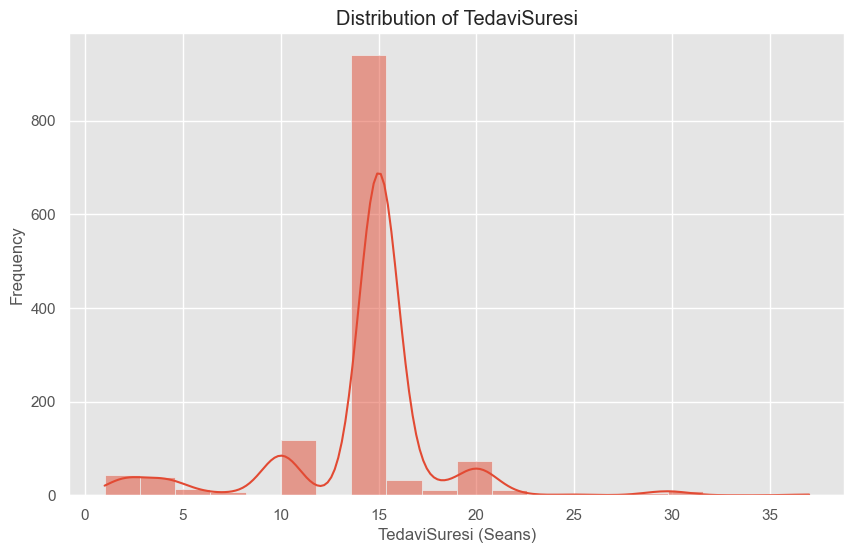

In [200]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TedaviSuresi'], bins=20, kde=True)
plt.title('Distribution of TedaviSuresi')
plt.xlabel('TedaviSuresi (Seans)')
plt.ylabel('Frequency')
plt.show()

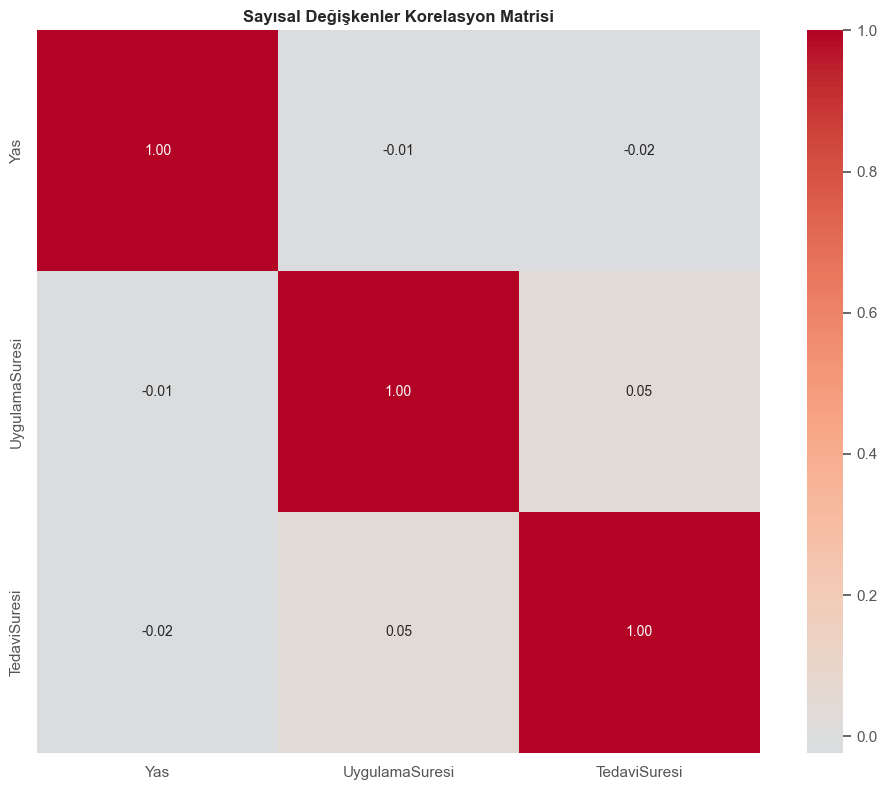

In [201]:
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Sayısal Değişkenler Korelasyon Matrisi', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Data Pre-Processing

## Eksik değerleri yönet

In [202]:
categorical_cols = ['Cinsiyet', 'KanGrubu', 'KronikHastalik', 'Bolum', 'Alerji', 'Tanilar', 'UygulamaYerleri']

for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

In [203]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
HastaNo            0
Yas                0
Cinsiyet           0
KanGrubu           0
Uyruk              0
KronikHastalik     0
Bolum              0
Alerji             0
Tanilar            0
TedaviAdi          0
TedaviSuresi       0
UygulamaYerleri    0
UygulamaSuresi     0
Yas_Grubu          0
dtype: int64


## Kategorik değişkenleri kodla

In [204]:
categorical_cols = ['Cinsiyet', 'KanGrubu', 'Uyruk', 'KronikHastalik', 'Bolum', 'Alerji', 'Tanilar', 'TedaviAdi', 'UygulamaYerleri', 'Yas_Grubu']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

In [205]:
display(df_encoded.head())
display(df_encoded.shape)

,HastaNo,Yas,TedaviSuresi,UygulamaSuresi,Cinsiyet_Erkek,Cinsiyet_Kadın,KanGrubu_0 Rh+,KanGrubu_0 Rh-,KanGrubu_A Rh+,KanGrubu_A Rh-,...,UygulamaYerleri_Sırt,"UygulamaYerleri_Sırt,Bel","UygulamaYerleri_Sırt,Omuz",UygulamaYerleri_Tüm Vücut Bölgesi,UygulamaYerleri_Yüz,Yas_Grubu_0-18,Yas_Grubu_19-30,Yas_Grubu_31-45,Yas_Grubu_46-60,Yas_Grubu_60+
0,145134,60,5,20,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,145135,28,15,20,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,145135,28,15,20,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,145135,28,15,5,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,145136,60,10,30,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


(1307, 940)

## Özellik ölçekleme

In [206]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Yas', 'UygulamaSuresi']

scaler = StandardScaler()

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [207]:
display(df_encoded.head())

,HastaNo,Yas,TedaviSuresi,UygulamaSuresi,Cinsiyet_Erkek,Cinsiyet_Kadın,KanGrubu_0 Rh+,KanGrubu_0 Rh-,KanGrubu_A Rh+,KanGrubu_A Rh-,...,UygulamaYerleri_Sırt,"UygulamaYerleri_Sırt,Bel","UygulamaYerleri_Sırt,Omuz",UygulamaYerleri_Tüm Vücut Bölgesi,UygulamaYerleri_Yüz,Yas_Grubu_0-18,Yas_Grubu_19-30,Yas_Grubu_31-45,Yas_Grubu_46-60,Yas_Grubu_60+
0,145134,0.824254,5,0.781556,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,145135,-1.251219,15,0.781556,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,145135,-1.251219,15,0.781556,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,145135,-1.251219,15,-1.287921,True,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,145136,0.824254,10,2.161208,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


## Özellikleri ve Hedefi Belirle

In [208]:
X = df_encoded.drop('TedaviSuresi', axis=1)
y = df_encoded['TedaviSuresi']

display(X.head())
display(y.head())

,HastaNo,Yas,UygulamaSuresi,Cinsiyet_Erkek,Cinsiyet_Kadın,KanGrubu_0 Rh+,KanGrubu_0 Rh-,KanGrubu_A Rh+,KanGrubu_A Rh-,KanGrubu_AB Rh+,...,UygulamaYerleri_Sırt,"UygulamaYerleri_Sırt,Bel","UygulamaYerleri_Sırt,Omuz",UygulamaYerleri_Tüm Vücut Bölgesi,UygulamaYerleri_Yüz,Yas_Grubu_0-18,Yas_Grubu_19-30,Yas_Grubu_31-45,Yas_Grubu_46-60,Yas_Grubu_60+
0,145134,0.824254,0.781556,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,145135,-1.251219,0.781556,True,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,145135,-1.251219,0.781556,True,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,145135,-1.251219,-1.287921,True,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,145136,0.824254,2.161208,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


0     5
1    15
2    15
3    15
6    10
Name: TedaviSuresi, dtype: object

## İşlenmiş Veriyi Kaydet

In [221]:
df_encoded.to_csv("../data/Talent_Academy_Case_DT_2025_preprocessed.csv", index=False)